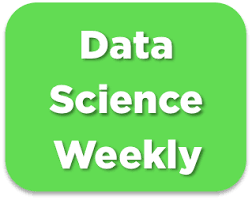

Le site Data Science Weekly propose une newsletter hebdomadaire dédiée à la science des données, à laquelle les utilisateurs peuvent s’inscrire en laissant leur adresse e-mail.  

L’objectif des data scientists derrière ce projet est double :  

Construire un modèle prédictif capable d’estimer la probabilité qu’un utilisateur s’abonne à la newsletter à partir de quelques variables (pays, âge, source, nombre de pages visités et statut).  
Analyser les facteurs explicatifs de cette conversion afin d’identifier les variables les plus influentes.  

À travers cette approche, ils cherchent non seulement à améliorer la performance prédictive, mais aussi à mieux comprendre le comportement des utilisateurs pour faire émerger des leviers concrets permettant d’augmenter le taux de conversion.  

# Import et configuration

In [ ]:
import pandas as pd
import numpy as np

import plotly.figure_factory as ff
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Création de la seed pour le machine learning
np.random.seed(42)

# Chargement des données

In [ ]:
print('Chargement du dataset...')
df = pd.read_csv('data/conversion_data_train.csv')
print('...Terminé.')

Chargement du dataset...
...Terminé.


# Audit qualité

In [359]:
# Comptage du nombre de lignes et colonnes
print(f'Nombre de lignes : {df.shape[0]}')
print(f'Nombre de colonnes : {df.shape[1]}\n')

print('Affichage du dataset :')
display(df.head())

print('Statistiques basiques :')
data_desc = df.describe(include='all')
display(data_desc)

print('Pourcentage de valeurs manquantes:')
display(100 * df.isnull().sum() / df.shape[0])

missing_values = df.isnull().any().any()
if missing_values :
    print('Il y a des valeurs manquantes dans le dataset')
else :
    print('Aucune valeur manquante dans le dataset')

print('\nVérification du type des données :')
df.info()

Nombre de lignes : 284580
Nombre de colonnes : 6

Affichage du dataset :


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


Statistiques basiques :


,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000,284580.000,284580,284580.000,284580.000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564,0.685,NaN,4.873,0.032
std,NaN,8.267,0.464,NaN,3.342,0.177
min,NaN,17.000,0.000,NaN,1.000,0.000
25%,NaN,24.000,0.000,NaN,2.000,0.000
50%,NaN,30.000,1.000,NaN,4.000,0.000
75%,NaN,36.000,1.000,NaN,7.000,0.000


Pourcentage de valeurs manquantes:


country               0.000
age                   0.000
new_user              0.000
source                0.000
total_pages_visited   0.000
converted             0.000
dtype: float64

Aucune valeur manquante dans le dataset

Vérification du type des données :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


Vérification des valeurs uniques pour chaque colonne catégorielles pour vérifier les doublons de nom et faire un mapping si nécessaire.

In [360]:
for column in df.columns.to_list():
    if df[column].dtypes == 'object':
        print(f'{column} : \n{df[column].unique()}')

country : 
['China' 'UK' 'Germany' 'US']
source : 
['Direct' 'Ads' 'Seo']


Pas de mapping nécessaire pour modifier le nom des valeurs et pas de nettoyage du dataset.

# EDA

Pour commencer, dans le describe nous avons vu des valeurs aberrantes au niveau de l'âge (âge maximum 123ans).  
Afin de prendre une décision par rapport à celles-ci, nous observons la distribution de l'âge.

In [ ]:
# box plot de la distribution de l'âge
age_dist = px.box(df, x='age')
age_dist.update_layout(
    title=dict(text="Distribution de l'âge", x=0.5),
    xaxis=dict(title=''),
    autosize=False, 
    width= 1000, 
    height=400
)
age_dist.show()

Avec ce graphique, nous observons qu'il y a seulement 2 valeurs au dessus de 80 ans (111 et 123 ans). Nous supprimerons ces lignes pour le machine learning.

In [362]:
# Suppression des lignes contenant les 2 outliers en utilisant mask (using masks)

print('Suppression des outliers dans la colonne âge...')
to_keep = (df['age'] < 100)  # Nous voulons supprimer les âges 111 et 123ans
df = df.loc[to_keep, :]
print(f'Fait. Nombre de lignes restantes : {df.shape[0]}')

Suppression des outliers dans la colonne âge...
Fait. Nombre de lignes restantes : 284578


In [363]:
# Matrice de corrélation avec les valeurs numériques
corr_matrix = df.corr(numeric_only=True).round(2)

matrix = ff.create_annotated_heatmap(corr_matrix.values,
                                  x = corr_matrix.columns.tolist(),
                                  y = corr_matrix.index.tolist())
matrix.update_layout(title=dict(text='Matrice de corrélation', x=0.5))
matrix.update_xaxes(side="bottom")
matrix.show()

La matrice de corrélation mets en avant une force corrélation entre le nombre de page visitées (total_pages_visited) et la cible (converted).  
Donc avec au moins cette données, nous savons que nous pourrons faire de bonnes prédictions !

In [364]:
# Création d'un dataframe de la distribution de la cible avec le taux en %
target = df['converted'].value_counts().reset_index()
target['taux_%'] = 100 * target['count'] / df.shape[0]
target['converted'] = target['converted'].map({0: 'Non', 1: 'Oui'})

# Transformation de 'converted' en string pour optimiser l'affichage
target['converted'] = target['converted'].astype(str)

# Création d'une catégorie unique pour affichage d'une barre empilée sur plotly
target['all'] = 'Distribution'

# Graphique de la distribution de la cible 'converted' avec affichage du pourcentage
target_dist = px.bar(
    target, 
    x='taux_%',
    y='all',  
    orientation='h',
    color='converted', 
    color_discrete_map={'Non': "orange", 'Oui': "blue"},
    labels={'taux_%': 'Taux (%)', 'converted': 'Convertis'}
)
target_dist.update_layout(
    title=dict(text='Taux de conversion global', x=0.5),
    xaxis=dict(title=''),
    yaxis=dict(title='Taux (%)'),
    autosize=False, 
    width= 800, 
    height=300,
    barmode='stack',
    plot_bgcolor='white',
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.2,
        xanchor="center",
        x=0.5
    )
)
target_dist.update_traces(
    texttemplate='%{x:.1f}%', 
    textposition='outside', 
    cliponaxis=False
)
target_dist.update_yaxes(showticklabels=False)
target_dist.update_xaxes(showticklabels=False,range=[0, 100])
target_dist.show()

converted = (df['converted'].value_counts()[1]) / (df['converted'].count()) *100
print(f'% de convertis : {round(converted,1)} %')

% de convertis : 3.2 %


Nous constatons que la cible est très déséquilibré ce qui nous sera utile pour le machine Learning.

In [365]:
# Graphique camenbert pour la distribution des pays
country_dist = px.pie(df, names='country')
country_dist.update_layout(title=dict(text='Distribution des pays', x=0.5))
country_dist.update_layout(autosize=False, width= 500, height=400)
country_dist.show()

La population des Etats-Unis est dominantes (56.3%) alors que celle de l'Allemagne est sous-représentée (4.11%) dans notre dataset.

In [366]:
# Création d'une copie du dataset
target_vs_other = df.copy()

# Transformation de 'new_user' en string pour optimiser l'affichage
target_vs_other['new_user'] = target_vs_other['new_user'].astype(str)

# Graphique du % de convertis pour en fonction de chaque colonnes individuellement
features = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
cols = 1
rows = (len(features) + cols - 1) // cols

fig_target_vs_other = make_subplots(
    rows=rows, 
    cols=cols, 
    subplot_titles=features
)
for i,column in enumerate(features):
    group = (
        target_vs_other
        .groupby([column,'converted'])
        .agg(count_converted=('converted', 'count'))
        .reset_index()
    )
    total = group.groupby(column)['count_converted'].transform('sum')
    group['taux_%'] = 100 * group['count_converted'] / total
    row = i // cols + 1 
    col = i % cols + 1
    group = group.loc[group['converted']==1,]
    fig_target_vs_other.add_trace(
        go.Bar(x=group[column], y=group['taux_%'], text=group['taux_%']),
        row=row,
        col=col
    )
fig_target_vs_other.update_layout(
    title=dict(
        text='Pourcentage de convertis en fonction des features',
        x=0.5, 
        font_color='blue'
    ),
    showlegend=False,
    width=1400, 
    height=1200
)
fig_target_vs_other.update_traces(
    textposition='outside', 
    cliponaxis=False, 
    textfont_size=10,
    texttemplate='%{text:.1f}%'
)
fig_target_vs_other.show()

Analyse de la variable cible (converted) en fonction des 5 features : 

- Pays : Malgré une sous-représentation de l'Allemagne, il s'agit du pays avec le plus haut taux de conversion (6.2%).  
- Age : Nous observons une conversion décroissante au fur et à mesure de l'augmentation de l'âge. Les utlisateurs les plus jeunes (17ans) présentent le taux de conversion le plus élevé (7.3%).  
- Nouvel utlisateur (new_user) : Les utilisateurs récurrents (new_user = 0) convertissent significativement plus (~7,2 %) que les nouveaux utilisateurs (1.4%). Cela suggère un effet de familiarité ou de confiance.
- Source : La source d’acquisition a un impact limité sur la conversion, avec des taux relativement homogènes (entre ~2,8 % et ~3,5 %).
- Nombre de pages visités : L'augmentation du nombre de page visitées est proportionnel à l'augmentation de la conversion. A noter que les utlisateurs ayant visités 21 pages ou plus semblent systématiquement convertis dans notre échantillon.  

Parmi les variables analysées, le nombre de pages visitées apparaît comme le facteur le plus explicatif de la conversion (ce que nous avions également vu grâce à la matrice de corrélation), suivi du statut de nouvel utilisateur. L’âge présente également une relation avec la conversion, avec une tendance décroissante à mesure que l’âge augmente. Toutefois, cet effet reste plus progressif que celui observé pour le nombre de pages visitées ou le statut de nouvel utilisateur. Les autres variables ont un impact plus modéré ou doivent être interprétées avec précaution. 

# Preprocessing  

Suite à l’audit qualité et à l’analyse exploratoire (EDA), aucune valeur manquante n’a été identifiée. Aucune imputation n’est donc nécessaire.

### Séparation de la cible Y : 'converted' et des autres features X

In [367]:
target_name = 'converted'

print('Séparation de la cible des features...')
Y = df.loc[:, target_name]
X = df.drop(target_name, axis=1)  # Toutes les colonnes sont convervés sauf la cible
print(f'...Fait.\n')
print('Cible :')
print(f'{Y.head()}\n')
print('Features :')
print(X.head())

Séparation de la cible des features...
...Fait.

Cible :
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

Features :
   country  age  new_user  source  total_pages_visited
0    China   22         1  Direct                    2
1       UK   21         1     Ads                    3
2  Germany   20         0     Seo                   14
3       US   23         1     Seo                    3
4       US   28         1  Direct                    3


### Train-test split

In [368]:
print("Division en ensembles d'entraînement et de test...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
#stratify sur y car cible déséquilibré ce qui garantit que le train et le test gardent la même proportion de convertis (~3,2 %
print('...Fait.')

Division en ensembles d'entraînement et de test...
...Fait.


### Pipeline : normalisation et encodage

In [369]:
# Détection automatique des colonnes numériques et catégorielles
numeric_features = []
categorical_features = []
for i,t in X.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print(f'Features numériques : {numeric_features}')
print(f'Features catégorielles : {categorical_features}')

Features numériques : ['age', 'new_user', 'total_pages_visited']
Features catégorielles : ['country', 'source']


In [370]:
print('Encodage des features catégorielles et standardisation des features numériques...')
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

# Utilisation d'un ColumnTransformer pour créer un objet préprocesseur qui décrit tous les traitements à effectuer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
print('...Fait.')

# Prétraitements appliqués au jeu d’entraînement
print(f'\nPrétraitements appliqués au jeu d entraînement...')
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('...Fait.')
print(X_train[0:3])

# Prétraitements appliqués au jeu de test
print(f'\nPrétraitements appliqués au jeu de test...')
print(X_test.head())
X_test = preprocessor.transform(X_test)  
print('...Fait.')
print(X_test[0:3, :])  


Encodage des features catégorielles et standardisation des features numériques...
...Fait.

Prétraitements appliqués au jeu d entraînement...
        country  age  new_user  source  total_pages_visited
14322        UK   37         1     Ads                    3
251570       UK   27         0     Seo                   13
53008        US   26         0  Direct                    4
121373       US   24         0     Seo                    1
151639  Germany   33         0     Ads                    2
...Fait.
[[ 0.77869487  0.67629326 -0.56105227  0.          0.          1.
   0.          1.          0.          0.        ]
 [-0.43027253 -1.47864847  2.43067457  0.          0.          1.
   0.          0.          0.          1.        ]
 [-0.55116927 -1.47864847 -0.26187958  0.          0.          0.
   1.          0.          1.          0.        ]]

Prétraitements appliqués au jeu de test...
       country  age  new_user  source  total_pages_visited
144383   China   37         1  Dir

### Entraînement du modèle de base

In [371]:
print('Entraînement du modèle...')
regressor = LogisticRegression(class_weight='balanced', random_state=42) 
#class-weight = 'balanced' car la cible est très déséquilibré ce qui donne plus de poids aux convertis qui sont minoritaires
regressor.fit(X_train, Y_train)
print('...Fait.')

Entraînement du modèle...
...Fait.


### Prédictions

In [372]:
# Prédictions sur le jeu d’entraînement
print('Prédictions sur le jeu d entraînement...')
Y_train_pred = regressor.predict(X_train)
print('...Fait.')
print(Y_train_pred[0:5])

# Prédictions sur le jeu d’entraînement
print(f'\nPrédictions sur le jeu de test...')
Y_test_pred = regressor.predict(X_test)
print('...Done.')
print(Y_test_pred[0:5])

Prédictions sur le jeu d entraînement...
...Fait.
[0 1 0 0 0]

Prédictions sur le jeu de test...
...Done.
[0 0 1 0 0]


### Évaluation des performances

In [373]:
# Ici, le score f1 sera utilisé pour évaluer les performances
print(f'f1-score sur le jeu de train : {f1_score(Y_train, Y_train_pred)}')
print(f'f1-score sur le jeu de test : {f1_score(Y_test, Y_test_pred)}')

f1-score sur le jeu de train : 0.511849045390387
f1-score sur le jeu de test : 0.5114617445668354


Le F1-score est stable entre le jeu d’entraînement (0,512) et le jeu de test (0,511), ce qui indique que le modèle ne présente pas de surapprentissage et généralise correctement.
Cependant, la performance globale reste modérée, ce qui suggère que le modèle capture une partie de l’information mais pourrait être amélioré.

Afin de comprendre les facteurs les plus déterminants dans la prédiction de la conversion, nous analysons les coefficients du modèle.

In [374]:
# Récupération des coefficients du modèle et du nom des features associées
coefficients = regressor.coef_[0]
features = preprocessor.get_feature_names_out().tolist()
# Nettoyage du nom des colonnes
features = pd.Series(features).str.replace('num__','').str.replace('cat__','')
# Création d'un dataframe avec les features et les coefficients
coef_df = pd.DataFrame({'Feature': features,'Coefficient': coefficients})
# Passage des coefficients en valeurs absolues
coef_df['Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
# Affichage des coefficients sous forme de graphique
fig_coef = px.bar(coef_df, x='Feature', y='Coefficient',text='Coefficient')
fig_coef.update_layout(
    title=dict(
        text='Coefficient du modèle de base',
        x=0.5, 
        font_color='blue'
    ),
    width=1400, 
    height=400  
)
fig_coef.update_traces(
    textposition='outside', 
    cliponaxis=False, 
    textfont_size=10,
    texttemplate='%{text:.2f}'
)
fig_coef.show()

Le graphique des coefficients montre que la variable la plus influente sur la conversion est le pays (notamment la Chine), suivie de près par le nombre de pages visitées. Ces deux variables ont un impact nettement supérieur aux autres, indiquant qu’elles jouent un rôle majeur dans la probabilité de conversion.

On observe également que certaines sources d’acquisition (Direct, SEO, Ads) ont une influence modérée, ce qui suggère que le canal d’entrée du trafic contribue également à la performance, mais dans une moindre mesure.

L’âge et le statut de nouvel utilisateur ont un effet plus limité mais non négligeable, tandis que les autres pays (États-Unis, Royaume-Uni, Allemagne) ont un impact faible sur le modèle.

### Optimisation du modèle de base avec un Gridsearch

In [375]:
print('Grid search...')
model = LogisticRegression(random_state=42)
params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [200, 500, 1000, 2000],
    'class_weight': [None, 'balanced']
}
glr = GridSearchCV(model, param_grid = params, cv = 5, scoring='f1', n_jobs=-1) 
glr.fit(X_train, Y_train)
print('...Fait.')
print(f'Meilleurs paramètres : {glr.best_params_}')
print(f'Meilleur F1 score : {glr.best_score_}')

Grid search...
...Fait.
Meilleurs paramètres : {'C': 10, 'class_weight': None, 'max_iter': 200}
Meilleur F1 score : 0.7641615688520307


Entraînement sur le jeu d'entraînement et de test avec les meilleurs paramètres pour vérifier si notre modèle fait preuve de surapprentissage et la qualité de sa prédiction suivant la classe à prédire.

In [376]:
best_model = glr.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

# Création d'un dictionnaire vide pour stocker le résultats des différents modèles testés
resultats ={}
# Stockage des résultats du modèle avec Gridsearch
resultats['Gridsearch_LogisticRegression'] = {
    'f1_binary_train': f1_score(Y_train, Y_train_pred, average='binary'),
    'f1_binary_test': f1_score(Y_test, Y_test_pred, average='binary'),

    'f1_macro_train': f1_score(Y_train, Y_train_pred, average='macro'),
    'f1_macro_test': f1_score(Y_test, Y_test_pred, average='macro'),

    'f1_weighted_train': f1_score(Y_train, Y_train_pred, average='weighted'),
    'f1_weighted_test': f1_score(Y_test, Y_test_pred, average='weighted'),
}
# f1_binary : performance sur la classe positive
# f1_macro : performance équilibrée entre les classes
# f1_weighted : performance globale influencée par la distribution des classes
for metric, score in resultats['Gridsearch_LogisticRegression'].items():
    print(f'{metric}: {score:.3f}')

f1_binary_train: 0.765
f1_binary_test: 0.759
f1_macro_train: 0.879
f1_macro_test: 0.876
f1_weighted_train: 0.986
f1_weighted_test: 0.985


Le GridSearch améliore nettement les performances du modèle par rapport au modèle de base (F1-score passant d’environ 0,51 à 0,76 sur le test), tout en conservant une bonne stabilité entre entraînement et test, ce qui indique l’absence de surapprentissage.  
Malgré cette amélioration, les performances restent déséquilibrées selon les classes, suggérant que le modèle est plus performant sur la classe majoritaire que sur la classe d’intérêt (convertis).  
En conclusion, l’optimisation des hyperparamètres a été efficace, mais des améliorations supplémentaires sont encore possibles pour mieux traiter le déséquilibre des classes.  

# Entraînement de 3 modèles différents et optimisation de ceux-ci

**Modèle Random Forest Classifier**

In [377]:
print('Entraînement du modèle...')
rfc = RandomForestClassifier(class_weight='balanced', random_state=42) 
rfc.fit(X_train, Y_train)
print('...Fait.')

# Prédictions sur le jeu d’entraînement et de test
print('Prédictions sur le jeu d entraînement et de test...')
Y_train_pred = rfc.predict(X_train)
Y_test_pred = rfc.predict(X_test)
print('...Fait.')

# Evaluation des performances
print(f'f1-score sur le jeu de train : {f1_score(Y_train, Y_train_pred)}')
print(f'f1-score sur le jeu de test : {f1_score(Y_test, Y_test_pred)}')

Entraînement du modèle...
...Fait.
Prédictions sur le jeu d entraînement et de test...
...Fait.
f1-score sur le jeu de train : 0.6414815499007066
f1-score sur le jeu de test : 0.5761426133131045


**Optimisation avec Gridsearch**

In [378]:
print('Grid search...')
model = RandomForestClassifier(random_state=42)

params = {
    'max_depth': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'n_estimators': [20, 50, 100],
    'class_weight': ['balanced', None]
}
grfc = GridSearchCV(model, param_grid=params, cv=3, scoring='f1', n_jobs=-1) 
grfc.fit(X_train, Y_train)
print('...Fait.')
print(f'Meilleurs paramètres : {grfc.best_params_}')
print(f'Meilleur F1 score : {grfc.best_score_}')

best_model = grfc.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

resultats['Gridsearch_RandomForestClassifier'] = {
    'f1_binary_train': f1_score(Y_train, Y_train_pred, average='binary'),
    'f1_binary_test': f1_score(Y_test, Y_test_pred, average='binary'),

    'f1_macro_train': f1_score(Y_train, Y_train_pred, average='macro'),
    'f1_macro_test': f1_score(Y_test, Y_test_pred, average='macro'),

    'f1_weighted_train': f1_score(Y_train, Y_train_pred, average='weighted'),
    'f1_weighted_test': f1_score(Y_test, Y_test_pred, average='weighted'),
}

Grid search...
...Fait.
Meilleurs paramètres : {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 20}
Meilleur F1 score : 0.7607480368691588


**Modèle XGB Classifier**

In [379]:
print('Entraînement du modèle...')
xgb = XGBClassifier(random_state=42) 
xgb.fit(X_train, Y_train)
print('...Fait.')

# Prédictions sur le jeu d’entraînement et de test
print('Prédictions sur le jeu d entraînement et de test...')
Y_train_pred = xgb.predict(X_train)
Y_test_pred = xgb.predict(X_test)
print('...Fait.')

# Evaluation des performances
print(f'f1-score sur le jeu de train : {f1_score(Y_train, Y_train_pred)}')
print(f'f1-score sur le jeu de test : {f1_score(Y_test, Y_test_pred)}')

Entraînement du modèle...
...Fait.
Prédictions sur le jeu d entraînement et de test...
...Fait.
f1-score sur le jeu de train : 0.7748068924539513
f1-score sur le jeu de test : 0.7579329102447869


**Optimisation avec Gridsearch**

In [380]:
print('Grid search...')
model = XGBClassifier(random_state=42)

params = {
    'max_depth': [2, 4, 6],  
    'n_estimators': [50, 100, 200], 
    'scale_pos_weight': [1, 2, 3],
    'learning_rate': [0.05, 0.1, 0.2]
}

gxgb = GridSearchCV(model, param_grid=params, cv=3, scoring='f1', n_jobs=-1)  
gxgb.fit(X_train, Y_train)
print('...Fait.')
print(f'Meilleurs paramètres : {gxgb.best_params_}')
print(f'Meilleur F1 score : {gxgb.best_score_}')

best_model = gxgb.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

resultats['Gridsearch_XGBClassifier'] = {
    'f1_binary_train': f1_score(Y_train, Y_train_pred, average='binary'),
    'f1_binary_test': f1_score(Y_test, Y_test_pred, average='binary'),

    'f1_macro_train': f1_score(Y_train, Y_train_pred, average='macro'),
    'f1_macro_test': f1_score(Y_test, Y_test_pred, average='macro'),

    'f1_weighted_train': f1_score(Y_train, Y_train_pred, average='weighted'),
    'f1_weighted_test': f1_score(Y_test, Y_test_pred, average='weighted'),
}

Grid search...
...Fait.
Meilleurs paramètres : {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 50, 'scale_pos_weight': 2}
Meilleur F1 score : 0.7675531233347046


**Modèle Gradient Boosting Classifier**

In [381]:
print('Entraînement du modèle...')
gbc = GradientBoostingClassifier(random_state=42) 
gbc.fit(X_train, Y_train)
print('...Fait.')

# Prédictions sur le jeu d’entraînement et de test
print('Prédictions sur le jeu d entraînement et de test...')
Y_train_pred = gbc.predict(X_train)
Y_test_pred = gbc.predict(X_test)
print('...Fait.')

# Evaluation des performances
print(f'f1-score sur le jeu de train : {f1_score(Y_train, Y_train_pred)}')
print(f'f1-score sur le jeu de test : {f1_score(Y_test, Y_test_pred)}')

Entraînement du modèle...
...Fait.
Prédictions sur le jeu d entraînement et de test...
...Fait.
f1-score sur le jeu de train : 0.7641481035520771
f1-score sur le jeu de test : 0.7566250380749314


In [382]:
print('Grid search...')
model = GradientBoostingClassifier(random_state=42)

params = {
    'max_depth': [2, 4, 6],  
    'n_estimators': [150, 200, 300],
    'learning_rate': [0.05, 0.1]
}

ggbc = GridSearchCV(model, param_grid=params, cv=3, scoring='f1', n_jobs=-1) 
ggbc.fit(X_train, Y_train)
print('...Fait.')
print(f'Meilleurs paramètres : {ggbc.best_params_}')
print(f'Meilleur F1 score : {ggbc.best_score_}')

best_model = ggbc.best_estimator_

Y_train_pred = best_model.predict(X_train)
Y_test_pred = best_model.predict(X_test)

resultats['Gridsearch_GradientBoosting'] = {
    'f1_binary_train': f1_score(Y_train, Y_train_pred, average='binary'),
    'f1_binary_test': f1_score(Y_test, Y_test_pred, average='binary'),

    'f1_macro_train': f1_score(Y_train, Y_train_pred, average='macro'),
    'f1_macro_test': f1_score(Y_test, Y_test_pred, average='macro'),

    'f1_weighted_train': f1_score(Y_train, Y_train_pred, average='weighted'),
    'f1_weighted_test': f1_score(Y_test, Y_test_pred, average='weighted'),
}

Grid search...
...Fait.
Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 150}
Meilleur F1 score : 0.7651668161160714


# Comparaison des résultats des 4 modèles

Comparaison des résultats des 4 modèles testés précédemment après optimisation par Gridsearch pour retenir le meilleur modèle.

In [383]:
pd.set_option('display.float_format', '{:.3f}'.format)
df_resultats = pd.DataFrame(resultats).T
display(df_resultats)

,f1_binary_train,f1_binary_test,f1_macro_train,f1_macro_test,f1_weighted_train,f1_weighted_test
Gridsearch_LogisticRegression,0.765,0.759,0.879,0.876,0.986,0.985
Gridsearch_RandomForestClassifier,0.773,0.757,0.883,0.875,0.986,0.985
Gridsearch_XGBClassifier,0.768,0.765,0.880,0.878,0.985,0.985
Gridsearch_GradientBoosting,0.770,0.757,0.882,0.875,0.986,0.985


Les différents modèles testés présentent des performances globalement proches, avec une bonne stabilité entre les scores d’entraînement et de test, indiquant l’absence de surapprentissage.

Le modèle XGBoost obtient le meilleur résultat avec un F1-score sur le jeu de test de 0,765, légèrement supérieur aux autres modèles. Cependant, l’écart avec la régression logistique reste faible (0,759), ce qui montre que les modèles plus complexes n’apportent qu’un gain marginal dans ce cas.

Les modèles de type Random Forest et Gradient Boosting n’améliorent pas significativement les performances, malgré une complexité plus élevée.

En conclusion, XGBoost constitue le meilleur choix en termes de performance, mais la régression logistique reste une alternative pertinente, plus simple et interprétable, avec des performances très proches.

# Analyse des performances du meilleur modèle et des facteurs influents

Nous analyserons les performances du modèle à l’aide d’une matrice de confusion et d’un graphique des importances des variables en valeur absolue.

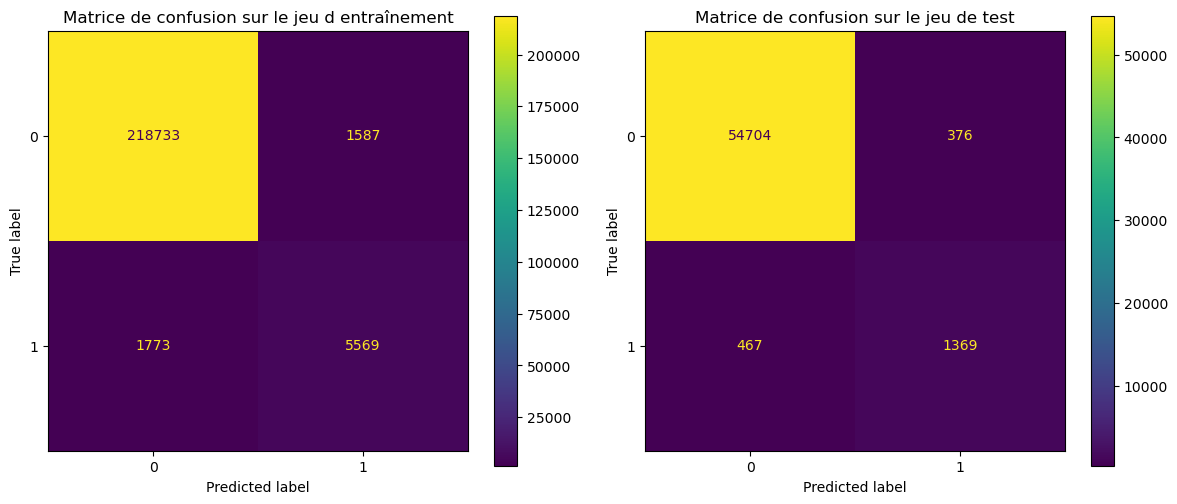

In [384]:
xgb = XGBClassifier(learning_rate= 0.2, max_depth= 2, n_estimators= 50, scale_pos_weight=2, random_state=42) 
xgb.fit(X_train, Y_train)
# Visualisation de la matrice de confusion
fig, ax = plt.subplots(1, 2, figsize=(12, 5)) 
ax[0].set(title='Matrice de confusion sur le jeu d entraînement')  
ConfusionMatrixDisplay.from_estimator(xgb, X_train, Y_train, ax=ax[0])

ax[1].set(title='Matrice de confusion sur le jeu de test')  
ConfusionMatrixDisplay.from_estimator(xgb, X_test, Y_test, ax=ax[1])
plt.tight_layout()  
plt.show()

In [385]:
# Vérification du taux de faux positif sur le train et le test
y_pred_train = xgb.predict(X_train)
matrix_train = confusion_matrix(Y_train, y_pred_train)
tn, fp, fn, tp = matrix_train.ravel()
fp_rate_train = fp / (fp + tn)

print(f'Taux de faux positif sur le jeu d entraînement : {round(fp_rate_train * 100, 2)} %')

y_pred_test = xgb.predict(X_test)
matrix_test = confusion_matrix(Y_test, y_pred_test)
tn, fp, fn, tp = matrix_test.ravel()
fp_rate_test = fp / (fp + tn)

print(f'Taux de faux positif sur le jeu de test : {round(fp_rate_test * 100, 2)} %')

Taux de faux positif sur le jeu d entraînement : 0.72 %
Taux de faux positif sur le jeu de test : 0.68 %


Il est généralement plus important de limiter les faux positifs afin d’éviter de cibler inutilement des utilisateurs non convertissants.  
Le modèle présente un taux de faux positifs très faible, stable entre le train (0,72 %) et le test (0,68 %), indiquant une bonne généralisation.  
Le meilleur modèle permet ainsi de limiter efficacement le ciblage d’utilisateurs non convertisseurs, ce qui optimise l’efficacité des actions marketing.  

Afin de comprendre les facteurs les plus déterminants dans la prédiction de la conversion, nous analysons l'importance des features pour notre meilleur modèle.

In [386]:
coefficients = xgb.feature_importances_
features = preprocessor.get_feature_names_out().tolist()
# Nettoyage du nom des colonnes
features = pd.Series(features).str.replace('num__','').str.replace('cat__','')
# Création d'un dataframe avec les features et les coefficients
coef_df = pd.DataFrame({'Feature': features,'Coefficient': coefficients})
# Passage des coefficients en valeurs absolues
coef_df['Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)
# Affichage des coefficients sous forme de graphique
fig_coef = px.bar(coef_df, x='Feature', y='Coefficient',text='Coefficient')
fig_coef.update_layout(
    title=dict(
        text='Feature importance du meilleur modèle',
        x=0.5, 
        font_color='blue'
    ),
    width=1400, 
    height=400  
)
fig_coef.update_traces(
    textposition='outside', 
    cliponaxis=False, 
    textfont_size=10,
    texttemplate='%{text:.2f}'
)
fig_coef.show()

Le modèle XGBoost optimisé confirme globalement les tendances observées dans le modèle de régression logistique, tout en affinant la hiérarchie des variables explicatives.  

- La variable total_pages_visited apparaît comme le facteur dominant de la conversion, avec un poids nettement supérieur aux autres variables. Cela confirme que l’engagement utilisateur est le principal moteur de la probabilité de conversion, et encore plus fortement capté par le modèle XGBoost que par le modèle de base.  
- Le statut de nouvel utilisateur devient le deuxième facteur le plus important, ce qui met en avant un effet structurel que la régression logistique sous-estimait légèrement.  
- La variable country_China reste fortement influente, mais son importance est désormais clairement derrière les variables comportementales, ce qui nuance légèrement la conclusion du modèle de base où l’effet des pays semblait plus dominant.  
- L’âge conserve un effet modéré, tandis que les autres pays (États-Unis, Royaume-Uni, Allemagne) ainsi que les sources d’acquisition (Direct, Ads, SEO) ont une importance très faible, voire quasi nulle dans le modèle XGBoost. Cela suggère que leur contribution réelle pour la prédiction est limitée.  

Dans l’ensemble, la comparaison des deux modèles montre que le facteur comportemental (engagement) est le plus déterminant et encore plus dominant dans le modèle non linéaire, les facteurs géographiques jouent un rôle secondaire mais stable, les variables liées au canal d’acquisition perdent en importance dans un modèle plus flexible.  

Ainsi, le passage de la régression logistique à XGBoost permet de mieux isoler les drivers réels de la conversion, en réduisant l’importance apparente de certaines variables corrélées dans le modèle linéaire.  

# Feature Engineering


Pour mieux traiter les déséquilibres et tenter d'améliorer les performances du meilleur modèle avec les meilleurs hyperparamètres (xgboost).

In [387]:
# Création d'une copie du jeu de données originel
df_engineered = df.copy()

In [388]:
# Création d'une colonne groupe d'âge
age_bins = [0, 25, 40, 60, 100]
age_labels = ['18-25', '26-40', '41-60', '60+']
df_engineered['age_group'] = pd.cut(df_engineered['age'],bins=age_bins,labels=age_labels,right=False)

# Regroupement des pays sous-représenté dans un groupe autre
df_engineered.loc[df_engineered['country'].isin(['Germany', 'UK']), 'country'] = 'other'

In [389]:
# Preprocessing
target_name = 'converted'
Y = df_engineered.loc[:, target_name]
X = df_engineered.drop(target_name, axis=1) 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# ajout de la colonne groupe d'âge dans les colonnes catégorielles
categorical_features = categorical_features + ['age_group']

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)  

In [390]:
print('Entraînement du modèle...')
xgb.fit(X_train, Y_train)
print('...Fait.')

# Prédictions sur le jeu d’entraînement et de test
print('Prédictions sur le jeu d entraînement et de test...')
Y_train_pred = xgb.predict(X_train)
Y_test_pred = xgb.predict(X_test)
print('...Fait.')

# Evaluation des performances
print(f'f1-score sur le jeu de train : {f1_score(Y_train, Y_train_pred)}')
print(f'f1-score sur le jeu de test : {f1_score(Y_test, Y_test_pred)}')

Entraînement du modèle...
...Fait.
Prédictions sur le jeu d entraînement et de test...
...Fait.
f1-score sur le jeu de train : 0.7681139380530974
f1-score sur le jeu de test : 0.7649201456990754


Suite à une première phase de feature engineering, quatre nouvelles variables ont été créées afin d’améliorer la performance du modèle.  

log_pages : Réduction de l’asymétrie du nombre de pages visitées via transformation logarithmique.  
age_x_pages : Interaction entre l’âge et l’engagement utilisateur (pages visitées).  
pages_group : Segmentation des utilisateurs selon le niveau de pages visitées (quartiles).  
new_user_x_pages : Interaction entre statut nouveau utilisateur et engagement (pages visitées).  

In [391]:
df_engineered['log_pages'] = np.log1p(df_engineered['total_pages_visited'])
df_engineered['age_x_pages'] = (df_engineered['age'] * df_engineered['total_pages_visited'])
df_engineered['pages_group'] = pd.qcut(df_engineered['total_pages_visited'], q=4, duplicates='drop')
df_engineered['new_user_x_pages'] = (df_engineered['new_user'] * df_engineered['total_pages_visited'])

In [392]:
# Preprocessing

target_name = 'converted'
Y = df_engineered.loc[:, target_name]
X = df_engineered.drop(target_name, axis=1) 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Ajout des 4 colonnes créées
numeric_features = numeric_features + ['log_pages', 'age_x_pages', 'new_user_x_pages']
categorical_features = categorical_features + ['pages_group']

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)  

In [393]:
print('Entraînement du modèle...')
xgb = XGBClassifier(learning_rate= 0.2, max_depth= 2, n_estimators= 50, scale_pos_weight=2, random_state=42) 
xgb.fit(X_train, Y_train)
print('...Fait.')

# Prédictions sur le jeu d’entraînement et de test
print('Prédictions sur le jeu d entraînement et de test...')
Y_train_pred = xgb.predict(X_train)
Y_test_pred = xgb.predict(X_test)
print('...Fait.')

# Evaluation des performances
print(f'f1-score sur le jeu de train : {f1_score(Y_train, Y_train_pred)}')
print(f'f1-score sur le jeu de test : {f1_score(Y_test, Y_test_pred)}')

Entraînement du modèle...
...Fait.
Prédictions sur le jeu d entraînement et de test...
...Fait.
f1-score sur le jeu de train : 0.7681139380530974
f1-score sur le jeu de test : 0.7649201456990754


Le feature engineering réalisé n’a pas permis d’améliorer significativement les performances des modèles. Les scores obtenus restent globalement stables par rapport aux modèles initiaux, avec des variations très faibles.  
Cela suggère que les variables d’origine contiennent déjà l’essentiel de l’information utile à la prédiction, et que les transformations ajoutées n’apportent pas de signal supplémentaire exploitable.  
En conséquence, les modèles atteignent probablement une limite de performance liée à la simplicité du jeu de données.  

Pour la prédiction à partir du dataset de test, nous conserverons les colonnes initiales sans feature engineering en utilisant le modèle le plus performant avec les hyperparamètres optimisés.

# Réentraînement du meilleur modèle sur toutes les données et prédiction sur le test
**Avant de faire des prédictions sur le fichier conversion_data_test.csv, entraînons notre modèle sur TOUTES les données qui se trouvaient dans conversion_data_train.csv. Parfois, cela permet d'apporter une petite amélioration au score car nous utilisons davantage d'exemples pour entraîner le modèle.**

In [394]:
# Réentraînement du modèle final avec les hyperparamètres optimisés
target_name = 'converted'

Y = df.loc[:, target_name]
X = df.drop(target_name, axis=1)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

numeric_features = ['age', 'new_user', 'total_pages_visited']
categorical_features = ['country', 'source']

# preprocessor déjà défini
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)  

best_model = XGBClassifier(learning_rate= 0.2, max_depth= 2, n_estimators= 50, scale_pos_weight=2, random_state=42) 
best_model.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [395]:
# Concaténation de toutes nos données pour entraîner le meilleur modèles sur toutes les données du fichier conversion_data_train
X_full = np.append(X_train,X_test,axis=0)
Y_full = np.append(Y_train,Y_test)

best_model.fit(X_full,Y_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [396]:
# Lecture des données du fichier conversion_data_test
data_without_labels = pd.read_csv('conversion_data_test.csv')
print(f'Ensemble de prédictions (sans étiquettes) : {data_without_labels.shape}')

features_list = ['country','age','new_user','source','total_pages_visited']
X_without_labels = data_without_labels.loc[:, features_list]

print('Encoding des colonnes catégorielles et standardisation des colonnes numériques...')
X_without_labels = preprocessor.transform(X_without_labels)
print('...Fait')
print(X_without_labels[0:5,:])

Ensemble de prédictions (sans étiquettes) : (31620, 5)
Encoding des colonnes catégorielles et standardisation des colonnes numériques...
...Fait
[[-0.30937579 -1.47864847  3.32819262  0.          0.          1.
   0.          0.          0.          1.        ]
 [-1.03475623  0.67629326  0.0372931   0.          0.          1.
   0.          0.          1.          0.        ]
 [ 0.17421117  0.67629326 -1.15939764  1.          0.          0.
   0.          0.          0.          1.        ]
 [ 0.17421117  0.67629326  0.33646578  0.          0.          0.
   1.          1.          0.          0.        ]
 [-0.67206601 -1.47864847 -0.56105227  1.          0.          0.
   0.          0.          0.          1.        ]]


In [ ]:
# Réalisation des prédictions et enregistrement du résultat sur un fichier csv dédié
data = {
    'converted': best_model.predict(X_without_labels)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('data/conversion_data_test_predictions_GREGORY_xgboost.csv', index=False)

In [398]:
# Vérification du fichier contenant les prédictions
data = pd.read_csv('conversion_data_test_predictions_GREGORY_xgboost.csv')
display(data.head(3))
data.value_counts(normalize=True) * 100

,converted
0,1
1,0
2,0


converted
0           96.907
1            3.093
Name: proportion, dtype: float64

En utilisant le modèle le plus performant avec les hyperparamètres optimisés (XGBoost), le dataset de test obtient un résultats de 3.093% de convertis.

# Pour aller plus loin  

Pour optimiser le taux de conversion, 3 idées à exploiter :   

- Maximiser l’engagement : Puisque total_pages_visited est de loin le facteur n°1, l'objectif business devient simple : faire naviguer davantage les utilisateurs qualifiés.  
    Pour cela, la navigation pourrait être simplifié (menus clairs, parcours guidé) ou des recommandations de contenu pourraient être ajoutées ("vous pourriez aimer").  
        L'idée étant que chaque page supplémentaire visité augmente fortement la probabilité de conversion.  
- Optimiser les parcours utilisateurs : Le modèle nous dit implicitement que ce n’est pas d’où vient l’utilisateur qui compte mais ce qu’il fait sur le site.  
    Pour cela, nous devrions identifier les pages où les utilisateurs quittent et réduire les frictions (formulaires trop longs, étapes inutiles).  
- Travailler spécifiquement les nouveaux utilisateurs : Le fait que new_user soit très important est un signal fort.  
    Pour cela, nous devrions roposer une offre de bienvenue (réduction, essai gratuit…) ou rassurer rapidement (preuves sociales, avis, garanties).  
        Les nouveaux utilisateurs sont souvent les plus “fragiles”, il faut les convaincre vite.


Le modèle donne déjà une bonne base mais il pourrait être amélioré, en ayant les informations suivantes à disposition :  

- Temps passé sur le site
- Type d’appareil (mobile vs desktop)
- Nombre de sessions
- Historique utilisateur (retours)

Ces informations peuvent aider à mieux capter l'engagement réel des utilisateurs.